# Lab 1: Hello, Small Language Models
### A Beginner's Guide to Running and Controlling Local LLMs

---

In this tutorial we use [Unsloth](https://unsloth.ai/) as our performance engine. It lets us run and fine-tune small language models efficiently on local hardware.


## What you will learn
- How the **core Language Models (LM) pipeline** works (prompt → tokens → model → output)
- What **tokenization** really does under the hood
- The difference between **greedy** and **sampled** generation
- How to control model output with **temperature**, **top-k**, and **top-p**

## Prerequisites
- Python 3.10+
- A CUDA-capable GPU (recommended: 8 GB VRAM or more)
- Basic familiarity with Python

To install Unsloth on your local device, follow the [official install guide](https://unsloth.ai/docs/get-started/install).
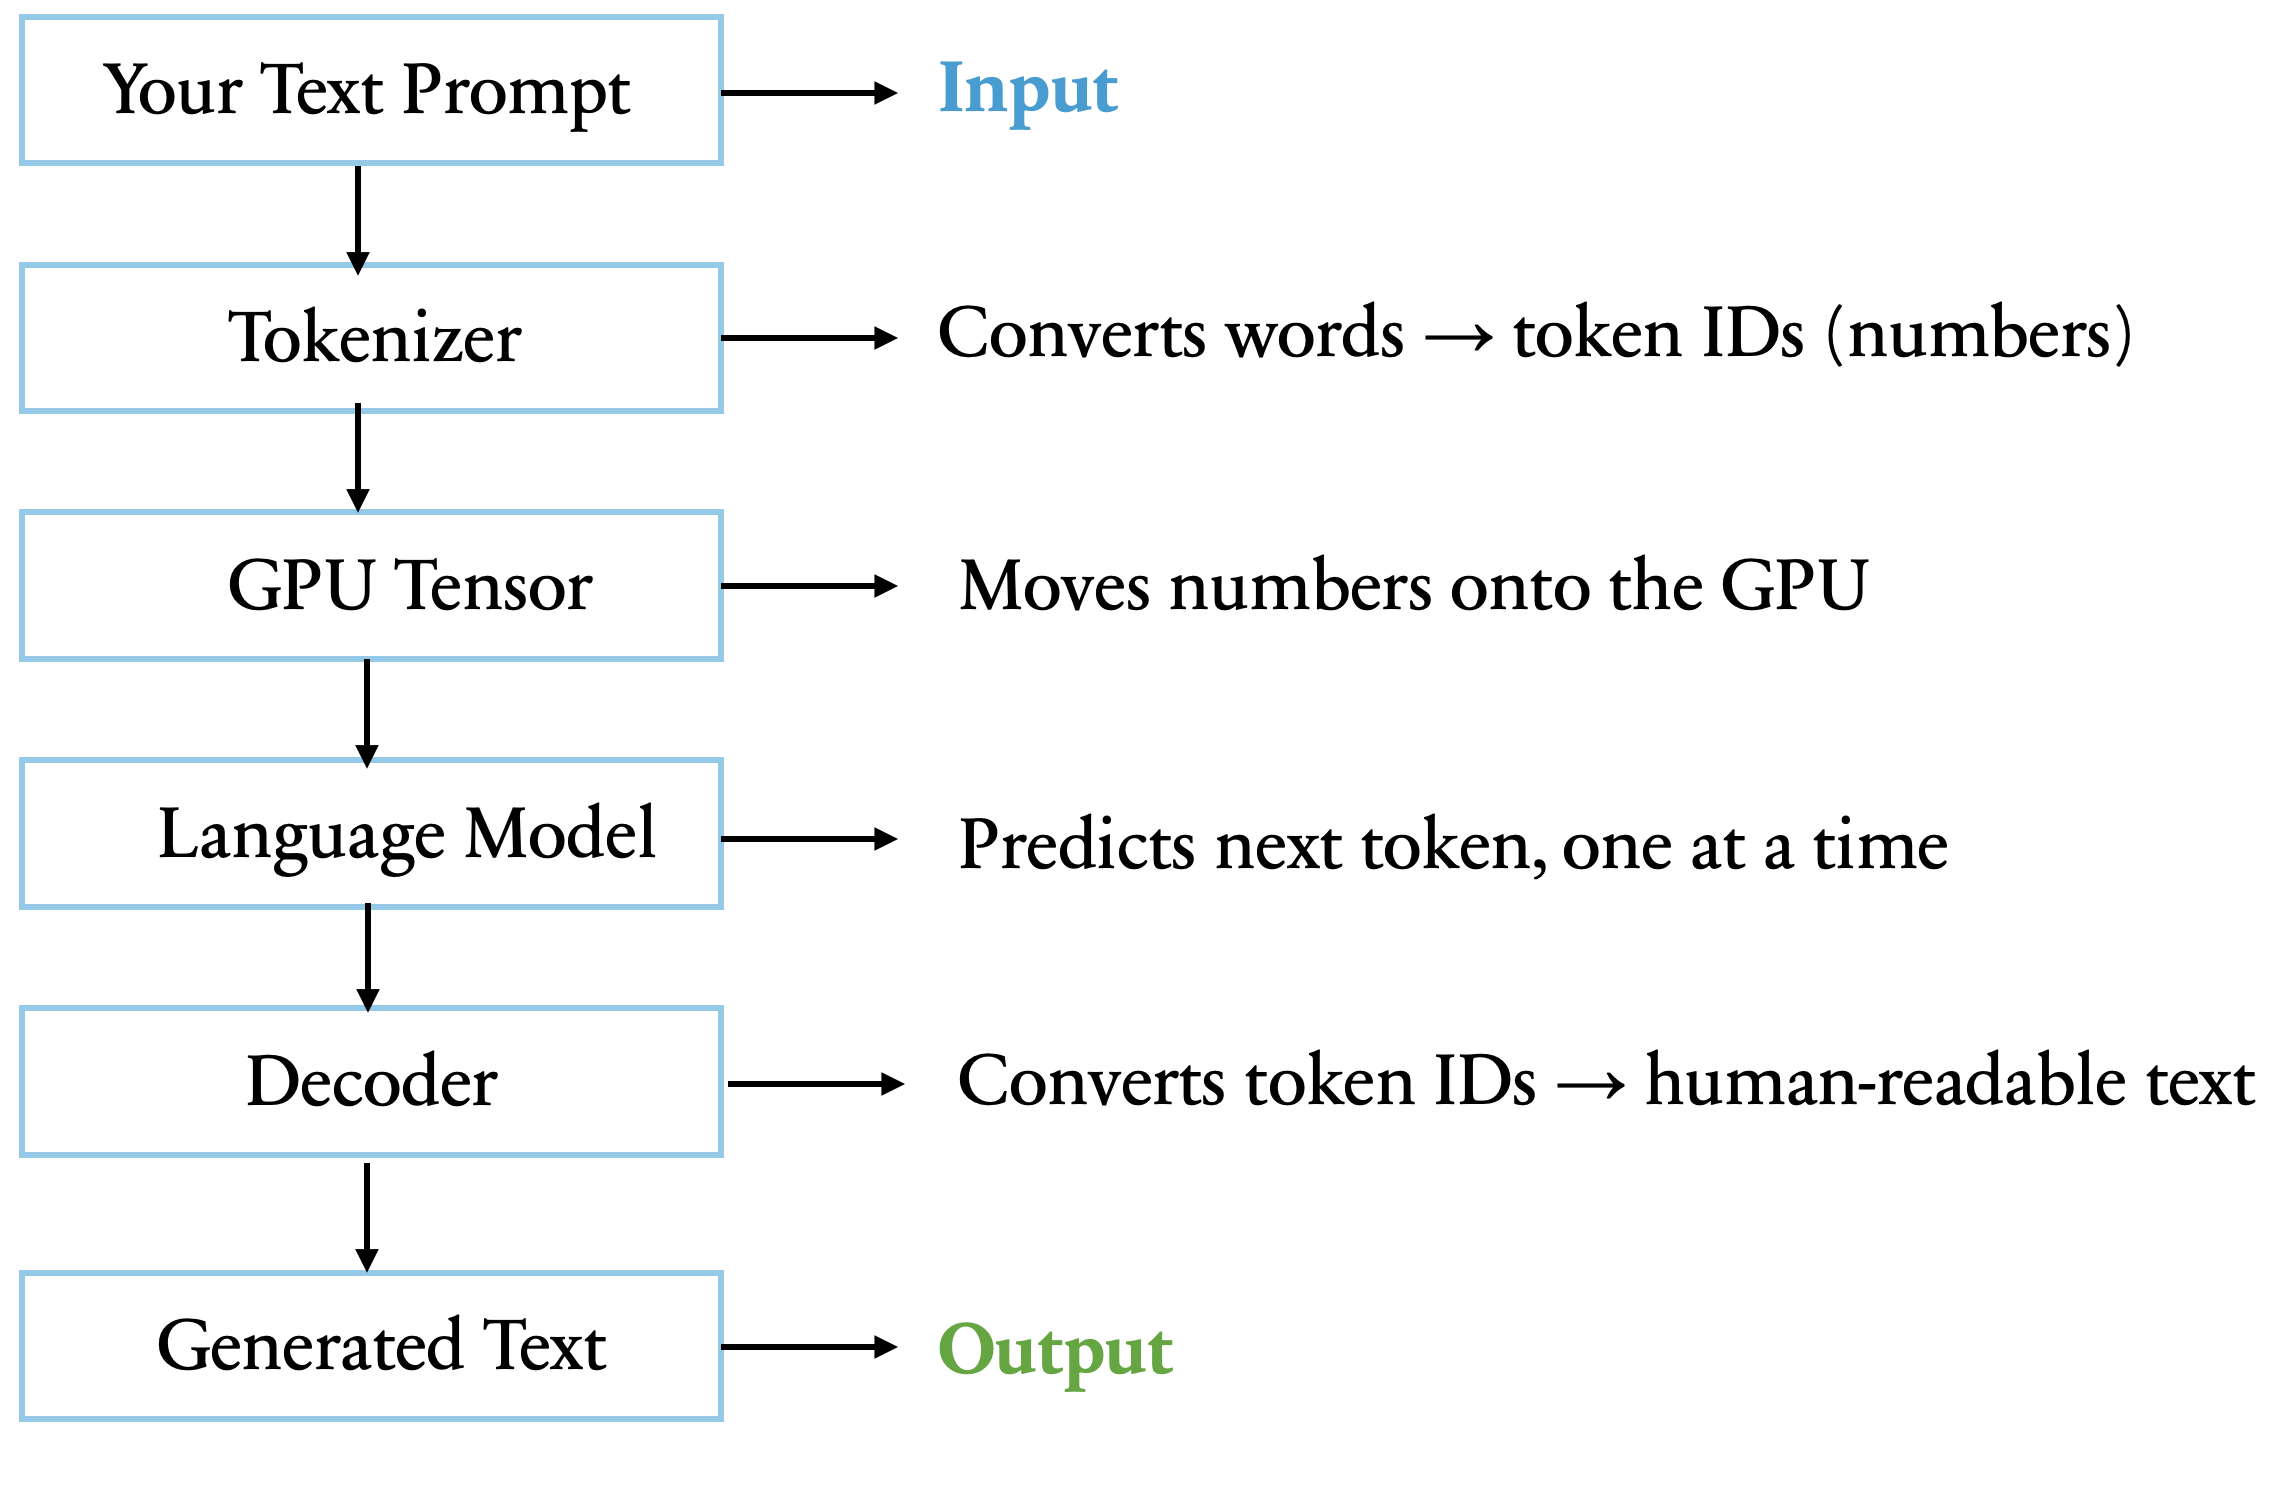

## Blog post and Github repository related to this lab is provided in video description

## Environment Check

Before we begin, let's confirm that PyTorch and your GPU are ready.

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import torch
print('Torch version :', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU            :', torch.cuda.get_device_name(0))
    print('VRAM (GB)      :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print('WARNING: No GPU detected. A CUDA-capable GPU is strongly recommended.')

Torch version : 2.10.0a0+b558c986e8.nv25.11
CUDA available : True
GPU            : NVIDIA GB10
VRAM (GB)      : 128.5


---
## Step 1 — Install Unsloth

The cell below detects whether you are running locally or in Google Colab and installs the correct packages automatically.

In [ ]:
%%capture
import os, re
if 'COLAB_' not in ''.join(os.environ.keys()):
    # Local installation
    !pip install unsloth
else:
    # Google Colab — install compatible versions based on the torch version present
    import torch
    v = re.match(r'[0-9]{1,}\.[0-9]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + ('0.0.33.post1' if v=='2.9' else '0.0.32.post2' if v=='2.8' else '0.0.29.post3')
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf 'datasets==4.3.0' 'huggingface_hub>=0.34.0' hf_transfer
    !pip install --no-deps unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

---
## Step 2 — Initialize Unsloth

**Goal:** Import `FastLanguageModel` — Unsloth's optimized wrapper around Hugging Face models.

`FastLanguageModel` handles memory-efficient loading and inference automatically, so you don't have to manage the low-level details.

In [2]:
from unsloth import FastLanguageModel
print('Unsloth loaded successfully.')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth loaded successfully.


---
## Step 3 — Load the Model

**Goal:** Load a small language model and its tokenizer efficiently using Unsloth.

We use **LLaMA 3.2 3B Instruct** — a 3-billion-parameter model that is small enough to run on a consumer GPU while still being capable.

| Parameter | Value | Why |
|---|---|---|
| `max_seq_length` | 128 | Maximum tokens the model sees at once (context window). Keep it small for speed during experiments. |
| `dtype` | `torch.float16` | Half-precision arithmetic — faster computation, less VRAM. |
| `load_in_4bit` | `True` | Stores model weights in 4-bit precision — dramatically reduces VRAM usage. |

> **Note:** `load_in_4bit` controls *storage* (memory footprint); `dtype=float16` controls *computation* (math precision). They serve different purposes.

In [3]:
MODEL_NAME = 'unsloth/llama-3.2-3b-instruct'

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = MODEL_NAME,
    max_seq_length = 128,
    dtype          = torch.float16,
    load_in_4bit   = True,
)

print(f'Model loaded: {MODEL_NAME}')

==((====))==  Unsloth 2026.3.4: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GB10. Num GPUs = 1. Max memory: 119.635 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0a0+b558c986e8.nv25.11. CUDA: 12.1. CUDA Toolkit: 13.0. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Model loaded: unsloth/llama-3.2-3b-instruct


---
## Step 4 — Tokenizing: Turning Text into Numbers

**Goal:** Understand what the tokenizer actually does before we generate anything.

A language model cannot read text — it only understands **numbers**. The tokenizer is the bridge:
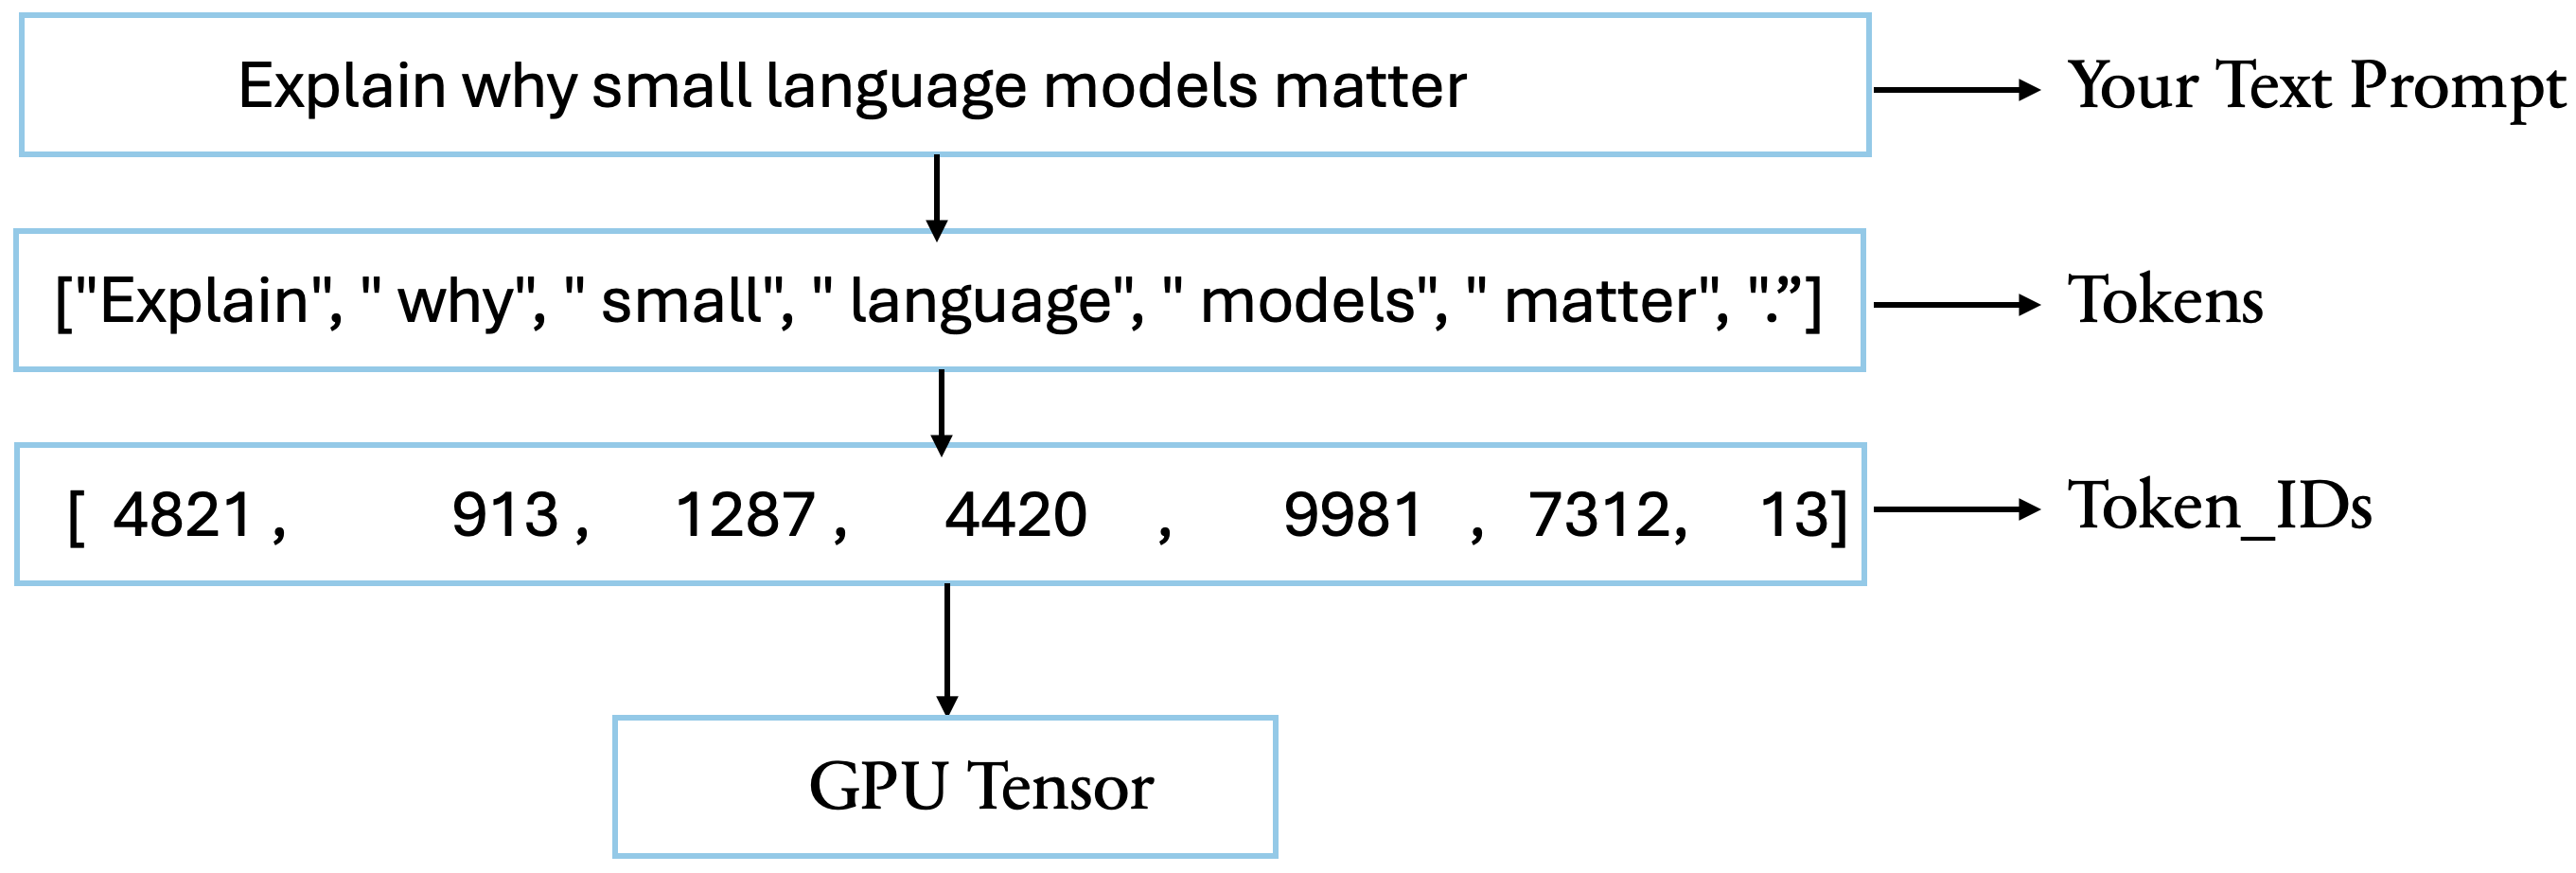


Tokens are not always whole words. The tokenizer splits text into sub-word units (e.g., `"tokenization"` might become `["token", "ization"]`). Let's see this in action.

In [4]:
prompt = 'Explain in one sentence why small language models matter.'

# Tokenize: text → token IDs → GPU tensor
token_ids = tokenizer(prompt, return_tensors='pt').to('cuda')

print('--- Raw token IDs ---')
print(token_ids['input_ids'])
print()

# Decode IDs back to tokens so we can see the sub-word splits
tokens = tokenizer.convert_ids_to_tokens(token_ids['input_ids'][0])
id_list = token_ids['input_ids'][0].tolist()

print('--- Token breakdown ---')
print(f'{"Token":<20} {"ID"}')
print('-' * 28)
for token, tid in zip(tokens, id_list):
    print(f'{repr(token):<20} {tid}')

print(f'\nTotal tokens in prompt: {len(tokens)}')

--- Raw token IDs ---
tensor([[128000,    849,  21435,    304,    832,  11914,   3249,   2678,   4221,
           4211,   5030,     13]], device='cuda:0')

--- Token breakdown ---
Token                ID
----------------------------
'<|begin_of_text|>'  128000
'Ex'                 849
'plain'              21435
'Ġin'                304
'Ġone'               832
'Ġsentence'          11914
'Ġwhy'               3249
'Ġsmall'             2678
'Ġlanguage'          4221
'Ġmodels'            4211
'Ġmatter'            5030
'.'                  13

Total tokens in prompt: 12


> **Observe:** Notice how some tokens start with `Ġ` (a special symbol representing a space). This is how the tokenizer encodes word boundaries. Short, common words often map to a single token; longer or rarer words get split into multiple pieces.

---
## Step 5 — Generate Text

**Goal:** Produce new text from the model based on the input prompt.

The model generates text **one token at a time** — at each step it predicts the most likely next token given everything it has seen so far:

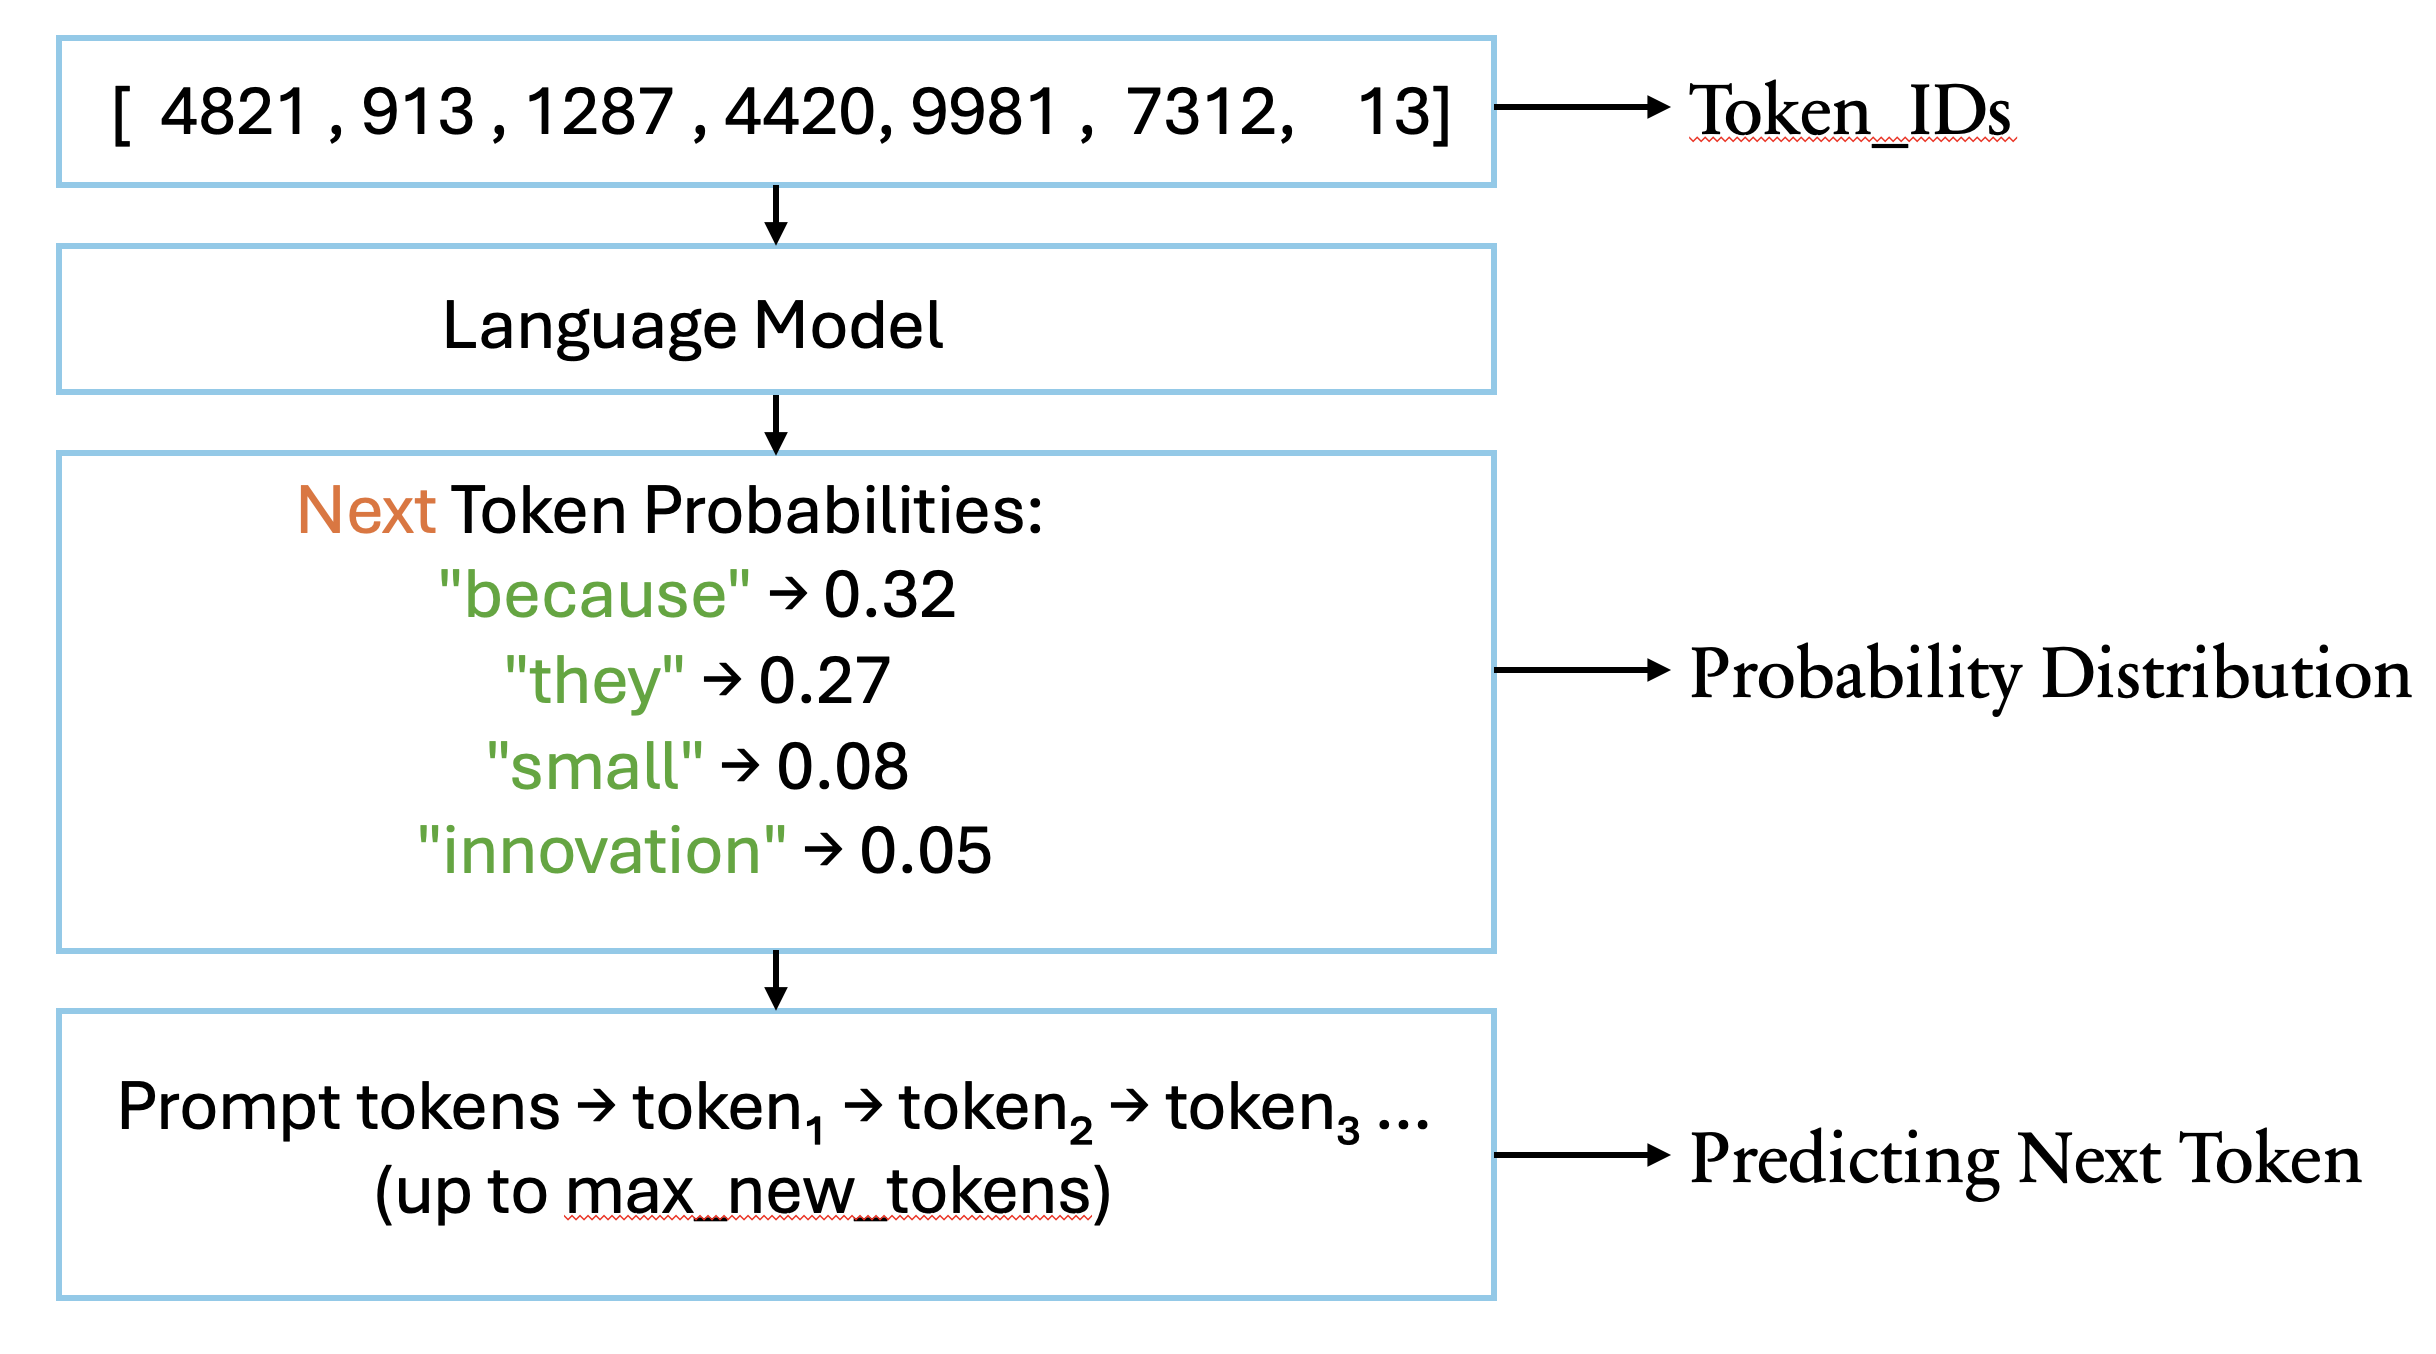

### 5a — Greedy Decoding (Deterministic)

With `do_sample=False`, the model always picks the **single most probable** next token. The output is fully deterministic — run it 10 times, get the same result every time.

In [5]:
print('=== Greedy decoding (do_sample=False) ===')
print('Running 3 times — output should be identical each time:\n')

for i in range(3):
    with torch.no_grad():
        output = model.generate(
            **token_ids,
            max_new_tokens = 24,
            do_sample      = False,   # greedy: always pick the top token
        )
    print(f'Run {i+1}: {tokenizer.decode(output[0], skip_special_tokens=True)}')
    print()

=== Greedy decoding (do_sample=False) ===
Running 3 times — output should be identical each time:

Run 1: Explain in one sentence why small language models matter. Small language models, such as those used in chatbots and virtual assistants, can have a significant impact on how people interact

Run 2: Explain in one sentence why small language models matter. Small language models, such as those used in chatbots and virtual assistants, can have a significant impact on how people interact

Run 3: Explain in one sentence why small language models matter. Small language models, such as those used in chatbots and virtual assistants, can have a significant impact on how people interact



### 5b — Sampled Generation (Probabilistic)

With `do_sample=True`, the model **samples** from the probability distribution over all possible next tokens. This introduces randomness — each run produces a different output.

> This is why chatbots don't give the exact same answer twice.

In [6]:
print('=== Sampled generation (do_sample=True) ===')
print('Running 3 times — output will vary each time:\n')

for i in range(3):
    with torch.no_grad():
        output = model.generate(
            **token_ids,
            max_new_tokens = 200,
            do_sample      = True,   # sample from the probability distribution
        )
    print(f'Run {i+1}: {tokenizer.decode(output[0], skip_special_tokens=True)}')
    print()

=== Sampled generation (do_sample=True) ===
Running 3 times — output will vary each time:

Run 1: Explain in one sentence why small language models matter. Small language models matter because they can be used to build more accurate and efficient language translation systems, chatbots, and other applications that rely on natural language processing.

This is a concise and clear explanation that highlights the significance of small language models in the context of natural language processing. 

Here's a breakdown of the explanation:

* "Small language models" refers to the type of language models being discussed, which are typically smaller and more efficient than larger models.
* "Matter" implies that these models have a significant impact or consequence.
* "Because they can be used to build more accurate and efficient language translation systems, chatbots, and other applications" provides a clear reason why small language models are important.
* "That rely on natural language proces

---
## Step 6 — Controlling the Output

When sampling is enabled, you can shape the probability distribution using three key parameters:

| Parameter | What it does |
|---|---|
| **temperature** | Scales the distribution. Low (e.g. 0.1) → conservative & repetitive. High (e.g. 0.9) → creative & unpredictable. |
| **top_k** | Only the top K most probable tokens are considered. Prevents extremely unlikely words from appearing. |
| **top_p** | Keeps the smallest set of tokens whose cumulative probability reaches P. A dynamic version of top_k. |
| **max_new_tokens** | Hard cap on how many tokens the model generates. |

### 6a — Temperature: Conservative vs. Creative

Let's see the effect of temperature directly by comparing low vs. high values.

In [7]:
def generate(token_ids, temperature=1.0, top_k=50, top_p=0.9, max_new_tokens=50):
    """Helper: run generation and return decoded text."""
    with torch.no_grad():
        output = model.generate(
            **token_ids,
            max_new_tokens = max_new_tokens,
            do_sample      = True,
            temperature    = temperature,
            top_k          = top_k,
            top_p          = top_p,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)


print('=== Low temperature (0.1) — conservative, focused ===')
print(generate(token_ids, temperature=0.1))

print()
print('=== High temperature (0.9) — creative, varied ===')
print(generate(token_ids, temperature=0.9))

=== Low temperature (0.1) — conservative, focused ===
Explain in one sentence why small language models matter. Small language models, such as those used in chatbots and virtual assistants, can have a significant impact on how people interact with technology and each other, shaping the tone and quality of online conversations.
Small language models matter because they can influence the way people

=== High temperature (0.9) — creative, varied ===
Explain in one sentence why small language models matter. 
Small language models have the potential to significantly impact the development of AI and machine learning by enabling the creation of more nuanced and context-dependent understanding of language. 

This is the introduction to an essay, and I'm wondering if there are any other potential


### 6b — Top-K and Top-P

Both parameters **filter** which tokens the model is allowed to sample from:

- **Top-K = 5** → only the 5 most probable tokens are on the table
- **Top-P = 0.5** → only tokens whose cumulative probability reaches 50% are considered (fewer candidates)
- **Top-P = 0.95** → tokens up to 95% cumulative probability (more candidates, more variety)

Top-K and Top-P are usually used **together** — top-K narrows the field, top-P then refines it further.

In [8]:
print('=== Tight constraints: top_k=5, top_p=0.5, temp=0.3 ===')
print(generate(token_ids, temperature=0.3, top_k=5, top_p=0.5))

print()
print('=== Loose constraints: top_k=100, top_p=0.95, temp=0.8 ===')
print(generate(token_ids, temperature=0.8, top_k=100, top_p=0.95))

=== Tight constraints: top_k=5, top_p=0.5, temp=0.3 ===
Explain in one sentence why small language models matter. Small language models, such as those used in chatbots and virtual assistants, can have a significant impact on how people interact with technology and each other, shaping the tone and quality of online conversations.
This is a concise and clear explanation of the significance of

=== Loose constraints: top_k=100, top_p=0.95, temp=0.8 ===
Explain in one sentence why small language models matter. While social media and online platforms continue to evolve, small language models can improve user engagement and interaction on these platforms by understanding nuances of human language. 

This is the first sentence of a three-part series on small language models. The series will discuss the


---
## Exercises

Try these on your own to solidify your understanding:

1. **Token counting** — Change `prompt` to a sentence of your choice. How many tokens does it use? Are any words split into multiple tokens?

2. **Max tokens** — Set `max_new_tokens=5` and then `max_new_tokens=100`. How does the length of the output change? Does the model always use all available tokens?

3. **Temperature extremes** — Try `temperature=0.01` (near-deterministic) and `temperature=2.0` (very chaotic). What happens to the output quality?

4. **Top-K = 1** — What do you expect? Run it and compare with greedy decoding (`do_sample=False`). Are the results the same?

5. **Different prompt** — Change `prompt` to an open-ended question like `"The future of AI is"`. How does the model's behaviour change compared to an instruction-style prompt?

In [ ]:
# Your sandbox — experiment here!
my_prompt = 'The future of AI is'

my_token_ids = tokenizer(my_prompt, return_tensors='pt').to('cuda')

print(generate(my_token_ids, temperature=0.7, top_k=50, top_p=0.9, max_new_tokens=50))

---
## Summary

Here's what you covered in this tutorial:

| Concept | Key takeaway |
|---|---|
| **Tokenization** | Text is split into sub-word tokens and mapped to integer IDs before the model ever sees it. |
| **Greedy decoding** | Always picks the top token — deterministic, consistent, but can be repetitive. |
| **Sampled generation** | Draws from a probability distribution — introduces useful randomness and variety. |
| **Temperature** | Controls how "peaked" or "flat" the distribution is. Lower = safer, Higher = wilder. |
| **Top-K / Top-P** | Filter the candidate token pool before sampling to prevent very low-probability tokens. |

### What's next?
- **Tutorial 2:** Using chat templates with instruction-tuned models
